In [88]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [89]:
circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [90]:
circles.label.value_counts()

,count
label,
1,500
0,500


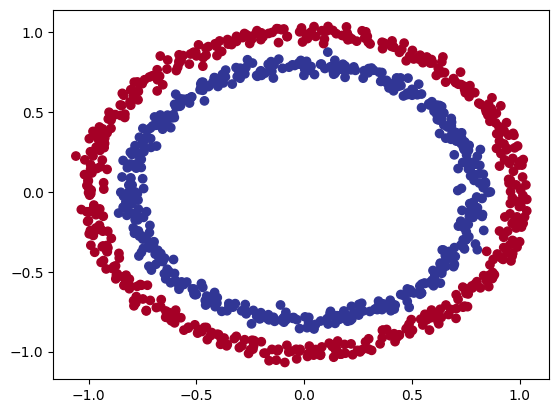

In [91]:
plt.scatter(x=X[:,0], y=X[:,1], c= y, cmap=plt.cm.RdYlBu);

In [92]:
X.shape, y.shape

((1000, 2), (1000,))

In [93]:
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample}\ny: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape}, y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074]
y: 1
Shapes for one sample of X: (2,), y: ()


In [94]:
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [95]:
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [96]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [97]:
class CircleModelv0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=5)
    self.layer2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x):
    return self.layer2(self.layer1(x))

model_0 = CircleModelv0().to(device)
model_0

CircleModelv0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [98]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [99]:
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.2484],
        [0.4491],
        [0.0465],
        [0.3043],
        [0.5610],
        [0.6795],
        [0.8367],
        [0.8920],
        [0.0251],
        [0.4682]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [100]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [101]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.2484],
        [0.4491],
        [0.0465],
        [0.3043],
        [0.5610]], device='cuda:0', grad_fn=<SliceBackward0>)

In [102]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5618],
        [0.6104],
        [0.5116],
        [0.5755],
        [0.6367]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [103]:
y_preds = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))
y_preds.squeeze()[:5]

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0', grad_fn=<SliceBackward0>)

In [104]:
torch.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train)
  accuracy = accuracy_score(y_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_0.eval()

  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_score(y_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72296 | Accuracy: 0.59% | test Loss: 0.72884 | Test Accuracy: 0.57%
Epoch: 10 | Loss: 0.71027 | Accuracy: 0.54% | test Loss: 0.71540 | Test Accuracy: 0.51%
Epoch: 20 | Loss: 0.70395 | Accuracy: 0.53% | test Loss: 0.70834 | Test Accuracy: 0.51%
Epoch: 30 | Loss: 0.70051 | Accuracy: 0.51% | test Loss: 0.70427 | Test Accuracy: 0.51%
Epoch: 40 | Loss: 0.69847 | Accuracy: 0.52% | test Loss: 0.70170 | Test Accuracy: 0.51%
Epoch: 50 | Loss: 0.69716 | Accuracy: 0.52% | test Loss: 0.69995 | Test Accuracy: 0.51%
Epoch: 60 | Loss: 0.69626 | Accuracy: 0.51% | test Loss: 0.69870 | Test Accuracy: 0.49%
Epoch: 70 | Loss: 0.69561 | Accuracy: 0.51% | test Loss: 0.69775 | Test Accuracy: 0.51%
Epoch: 80 | Loss: 0.69513 | Accuracy: 0.51% | test Loss: 0.69702 | Test Accuracy: 0.51%
Epoch: 90 | Loss: 0.69476 | Accuracy: 0.50% | test Loss: 0.69643 | Test Accuracy: 0.51%


In [105]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("Helper_function.py already exists, skipping downloading.....!")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

Helper_function.py already exists, skipping downloading.....!


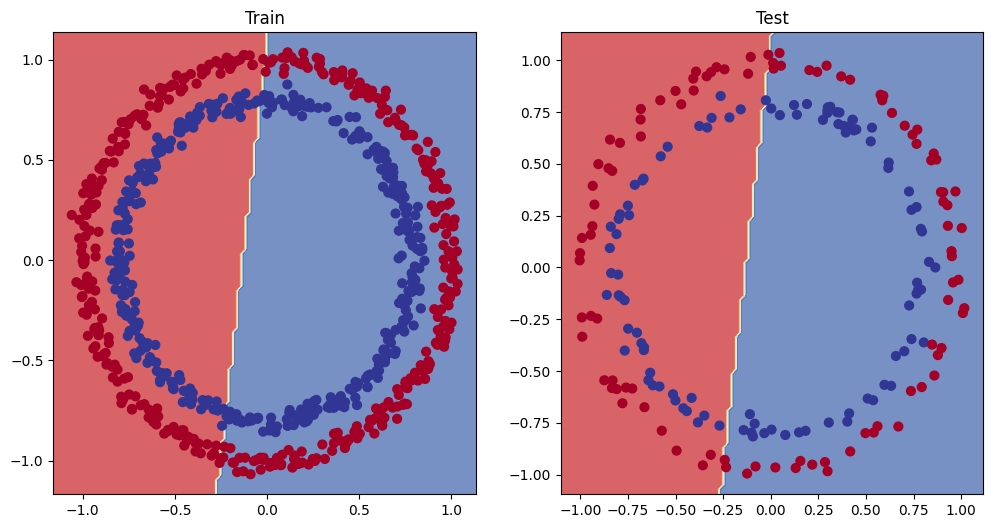

In [106]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [107]:
class CircleModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelv1().to(device)
model_1

CircleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [108]:
loss_fn = nn.BCEWithLogitsLoss()
opimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [109]:
torch.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train)
  accuracy = accuracy_score(y_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  opimizer.zero_grad()
  loss.backward()
  opimizer.step()
  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_score(y_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Accuracy: 0.51% | test Loss: 0.69261 | Test Accuracy: 0.51%
Epoch: 100 | Loss: 0.69305 | Accuracy: 0.50% | test Loss: 0.69379 | Test Accuracy: 0.48%
Epoch: 200 | Loss: 0.69299 | Accuracy: 0.51% | test Loss: 0.69437 | Test Accuracy: 0.46%
Epoch: 300 | Loss: 0.69298 | Accuracy: 0.52% | test Loss: 0.69458 | Test Accuracy: 0.45%
Epoch: 400 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69465 | Test Accuracy: 0.46%
Epoch: 500 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69467 | Test Accuracy: 0.46%
Epoch: 600 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69468 | Test Accuracy: 0.46%
Epoch: 700 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69468 | Test Accuracy: 0.46%
Epoch: 800 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69468 | Test Accuracy: 0.46%
Epoch: 900 | Loss: 0.69298 | Accuracy: 0.51% | test Loss: 0.69468 | Test Accuracy: 0.46%


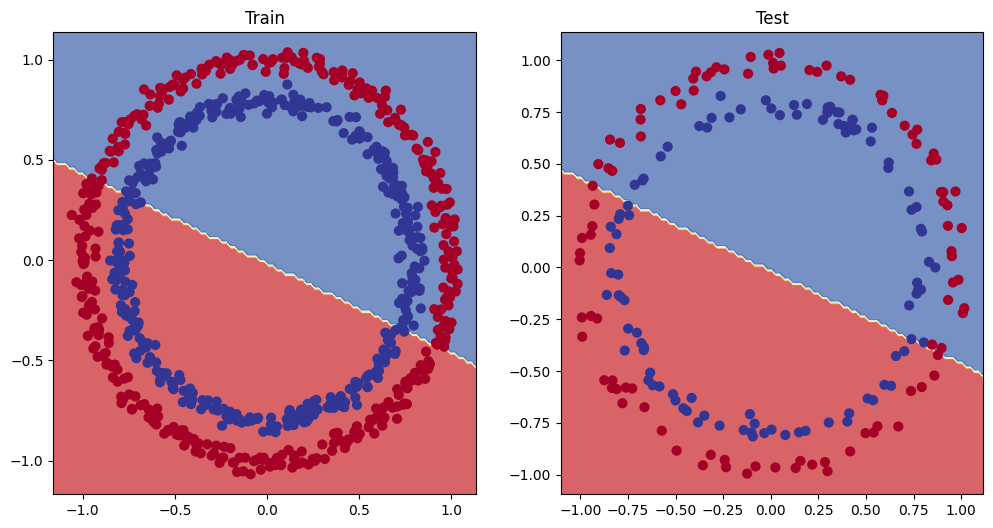

In [110]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [111]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [112]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

print(len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression))

80 80 20 20


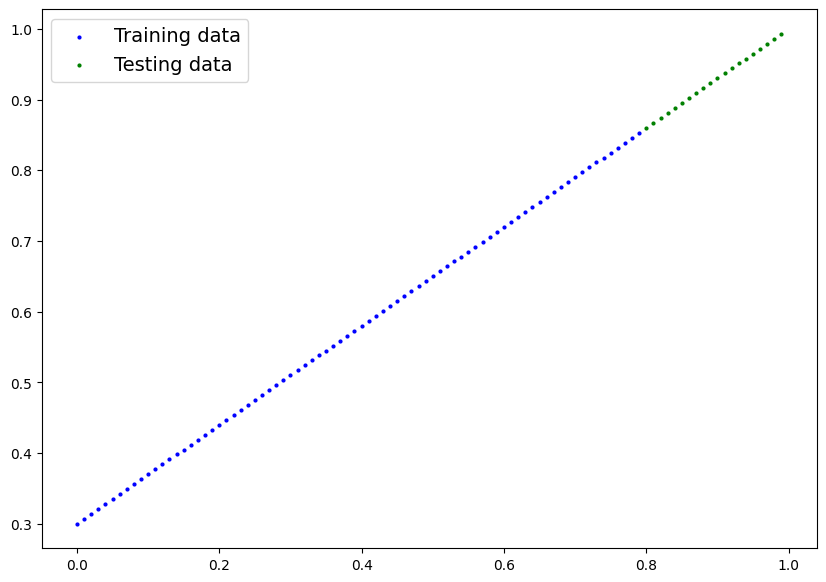

In [113]:
plot_predictions(train_data=X_train_regression, train_labels=y_train_regression, test_data=X_test_regression, test_labels=y_test_regression)

In [114]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [115]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [116]:
torch.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.75986 | Accuracy: 0.51% | test Loss: 0.91103 | Test Accuracy: 0.46%
Epoch: 100 | Loss: 0.02858 | Accuracy: 0.51% | test Loss: 0.00081 | Test Accuracy: 0.46%
Epoch: 200 | Loss: 0.02533 | Accuracy: 0.51% | test Loss: 0.00209 | Test Accuracy: 0.46%
Epoch: 300 | Loss: 0.02137 | Accuracy: 0.51% | test Loss: 0.00305 | Test Accuracy: 0.46%
Epoch: 400 | Loss: 0.01964 | Accuracy: 0.51% | test Loss: 0.00341 | Test Accuracy: 0.46%
Epoch: 500 | Loss: 0.01940 | Accuracy: 0.51% | test Loss: 0.00387 | Test Accuracy: 0.46%
Epoch: 600 | Loss: 0.01903 | Accuracy: 0.51% | test Loss: 0.00379 | Test Accuracy: 0.46%
Epoch: 700 | Loss: 0.01878 | Accuracy: 0.51% | test Loss: 0.00381 | Test Accuracy: 0.46%
Epoch: 800 | Loss: 0.01840 | Accuracy: 0.51% | test Loss: 0.00329 | Test Accuracy: 0.46%
Epoch: 900 | Loss: 0.01798 | Accuracy: 0.51% | test Loss: 0.00360 | Test Accuracy: 0.46%


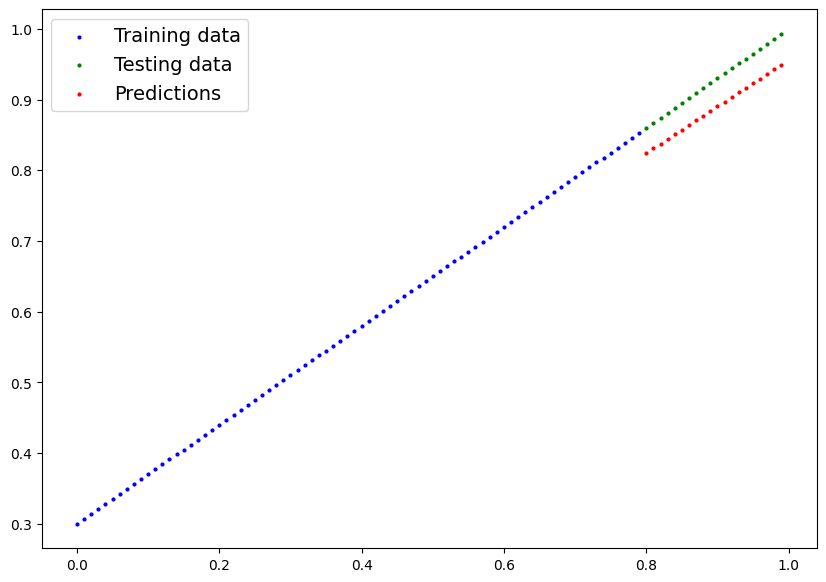

In [117]:
model_2.eval()

with torch.inference_mode():
  y_preds = model_2(X_test_regression)
plot_predictions(train_data=X_train_regression.cpu(), train_labels=y_train_regression.cpu(), test_data=X_test_regression.cpu(), test_labels=y_test_regression.cpu(), predictions=y_preds.cpu())

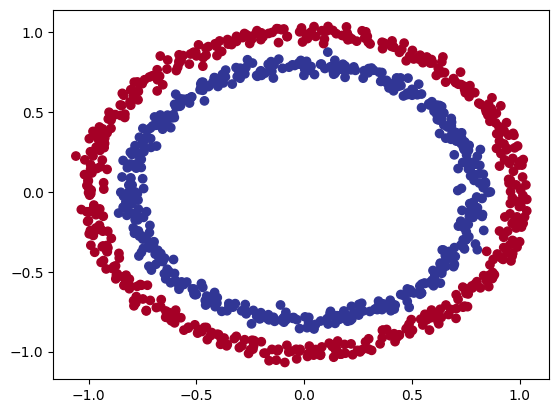

In [118]:
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [119]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [120]:
class CircleModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.layer_2(self.relu(self.layer_1(x))))

model_3 = CircleModelv2().to(device)
model_3

CircleModelv2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [121]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [122]:
torch.manual_seed(42)
epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_score(y_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_3.eval()

  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_score(y_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())
    test_loss = loss_fn(test_logits, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69441 | Accuracy: 0.51% | test Loss: 0.69412 | Test Accuracy: 0.50%
Epoch: 100 | Loss: 0.68984 | Accuracy: 0.51% | test Loss: 0.68935 | Test Accuracy: 0.51%
Epoch: 200 | Loss: 0.68707 | Accuracy: 0.51% | test Loss: 0.68601 | Test Accuracy: 0.59%
Epoch: 300 | Loss: 0.68338 | Accuracy: 0.51% | test Loss: 0.68177 | Test Accuracy: 0.58%
Epoch: 400 | Loss: 0.67826 | Accuracy: 0.51% | test Loss: 0.67591 | Test Accuracy: 0.57%
Epoch: 500 | Loss: 0.67058 | Accuracy: 0.51% | test Loss: 0.66753 | Test Accuracy: 0.58%
Epoch: 600 | Loss: 0.65828 | Accuracy: 0.51% | test Loss: 0.65466 | Test Accuracy: 0.59%
Epoch: 700 | Loss: 0.63517 | Accuracy: 0.51% | test Loss: 0.63262 | Test Accuracy: 0.75%
Epoch: 800 | Loss: 0.59027 | Accuracy: 0.51% | test Loss: 0.59330 | Test Accuracy: 0.87%
Epoch: 900 | Loss: 0.51050 | Accuracy: 0.51% | test Loss: 0.52613 | Test Accuracy: 0.91%


In [123]:
model_3.eval()

with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y[:10]

(tensor([1., 1., 1., 0., 1., 1., 0., 0., 1., 1.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

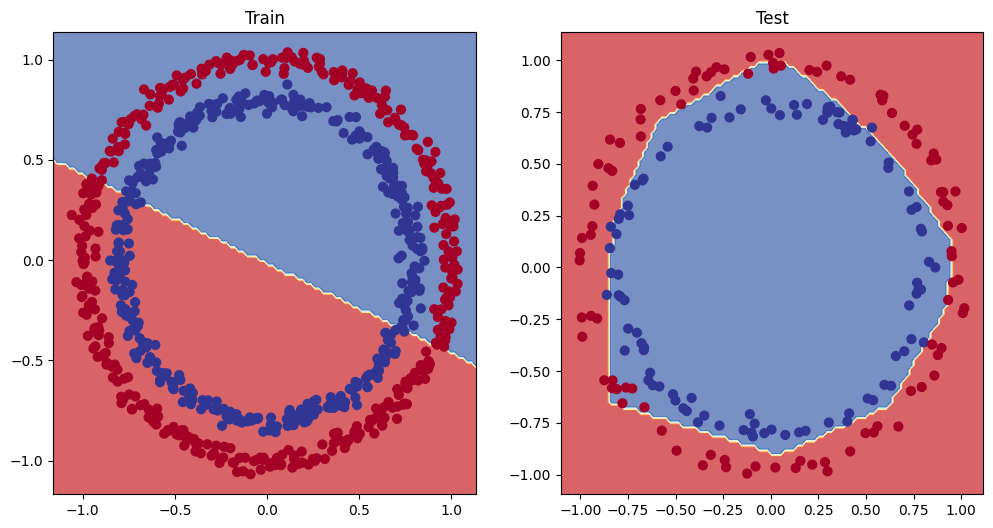

In [124]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [125]:
A = torch.arange(-10, 10 , 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

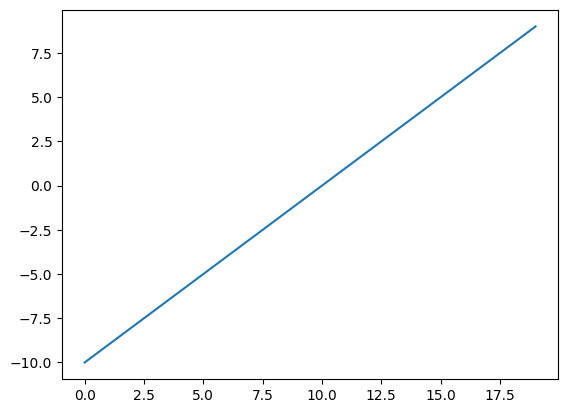

In [126]:
plt.plot(A)

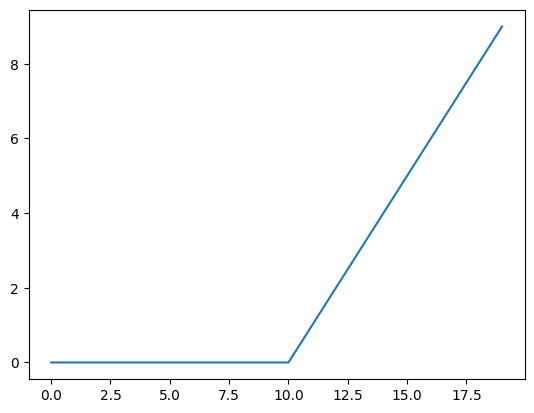

In [127]:
plt.plot(torch.relu(A))

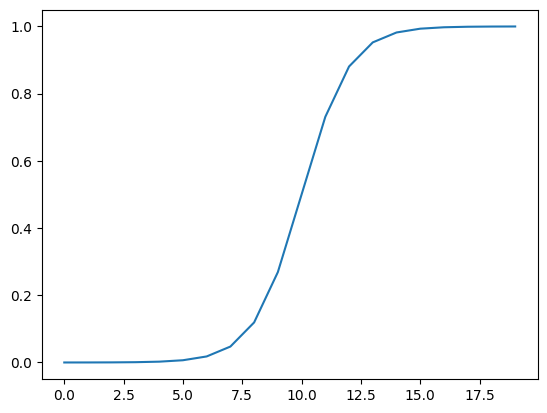

In [128]:
plt.plot(torch.sigmoid(A))

In [129]:
from sklearn.datasets import make_blobs

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers = NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
X_blob[:5], y_blob[:5]

(tensor([[-8.4134,  6.9352],
         [-5.7665, -6.4312],
         [-6.0421, -6.7661],
         [ 3.9508,  0.6984],
         [ 4.2505, -0.2815]]),
 tensor([3, 2, 2, 1, 1]))

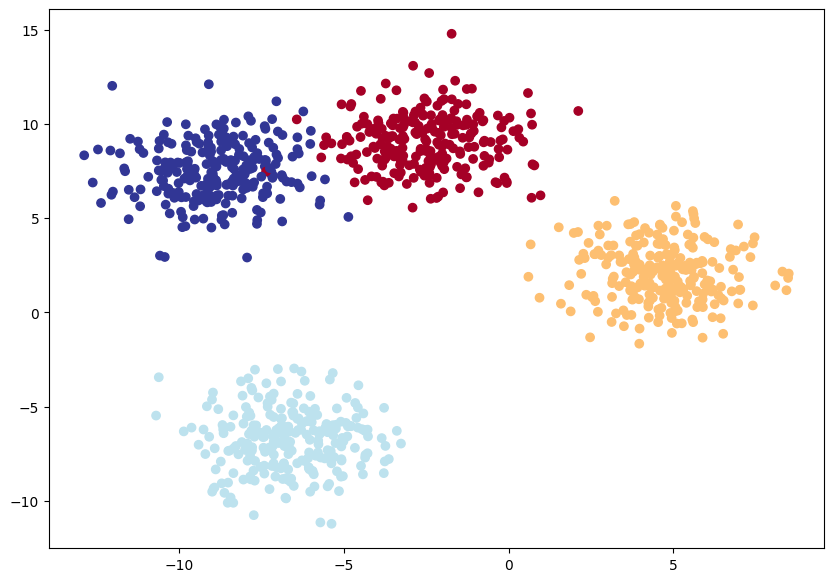

In [130]:
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [131]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [132]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 0):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )
  def forward(self, x):
    return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=NUM_FEATURES, output_features=NUM_CLASSES, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [133]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

In [134]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

In [135]:
model_4(X_blob_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [136]:
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

In [137]:
y_logits = model_4(X_blob_test.to(device))
y_pred_probs = torch.softmax(y_logits, dim=1)
y_logits[:5], y_pred_probs[:5]

(tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
         [ 1.7168, -1.2270,  1.7367,  2.1010],
         [ 2.2400,  0.7714,  2.6020,  1.0107],
         [-0.7993, -0.3723, -0.9138, -0.5388],
         [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0',
        grad_fn=<SliceBackward0>),
 tensor([[0.1872, 0.2918, 0.1495, 0.3715],
         [0.2824, 0.0149, 0.2881, 0.4147],
         [0.3380, 0.0778, 0.4854, 0.0989],
         [0.2118, 0.3246, 0.1889, 0.2748],
         [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0',
        grad_fn=<SliceBackward0>))

In [138]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [139]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [140]:
y_pred_probs[0], torch.argmax(y_pred_probs[0])

(tensor([0.1872, 0.2918, 0.1495, 0.3715], device='cuda:0',
        grad_fn=<SelectBackward0>),
 tensor(3, device='cuda:0'))

In [141]:
torch.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_score(y_blob_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()

  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_score(y_blob_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {accuracy:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.04324 | Accuracy: 0.51% | test Loss: 0.57861 | Test Accuracy: 0.95%
Epoch: 10 | Loss: 0.14398 | Accuracy: 0.51% | test Loss: 0.13037 | Test Accuracy: 0.99%
Epoch: 20 | Loss: 0.08062 | Accuracy: 0.51% | test Loss: 0.07216 | Test Accuracy: 0.99%
Epoch: 30 | Loss: 0.05924 | Accuracy: 0.51% | test Loss: 0.05133 | Test Accuracy: 0.99%
Epoch: 40 | Loss: 0.04892 | Accuracy: 0.51% | test Loss: 0.04098 | Test Accuracy: 0.99%
Epoch: 50 | Loss: 0.04295 | Accuracy: 0.51% | test Loss: 0.03486 | Test Accuracy: 0.99%
Epoch: 60 | Loss: 0.03910 | Accuracy: 0.51% | test Loss: 0.03083 | Test Accuracy: 0.99%
Epoch: 70 | Loss: 0.03643 | Accuracy: 0.51% | test Loss: 0.02799 | Test Accuracy: 0.99%
Epoch: 80 | Loss: 0.03448 | Accuracy: 0.51% | test Loss: 0.02587 | Test Accuracy: 0.99%
Epoch: 90 | Loss: 0.03300 | Accuracy: 0.51% | test Loss: 0.02423 | Test Accuracy: 0.99%


In [142]:
model_4.eval()

with torch.inference_mode():
  y_logits = model_4(X_blob_test)
y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0726,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5309,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]], device='cuda:0')

In [143]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_preds = y_pred_probs.argmax(dim=1)
y_preds[:10], y_blob_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0'))

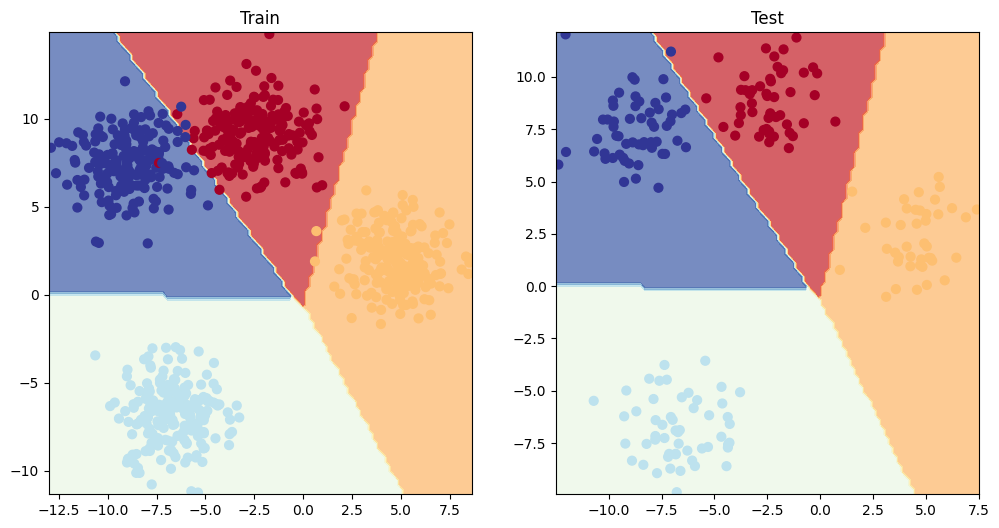

In [144]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

# **Excersize**

In [145]:
from sklearn.datasets import make_moons

n_samples = 1000
X, y = make_moons(n_samples, noise=0.03, random_state=42)
X[:5], y[:5]

(array([[-0.00933187,  0.39098105],
        [ 0.95457387, -0.47375583],
        [ 0.9185256 , -0.42519648],
        [ 0.41276802, -0.37638459],
        [-0.84532016,  0.52879908]]),
 array([1, 1, 1, 1, 0]))

In [146]:
df = pd.DataFrame({"X1": X[:, 0], "X2": X[:,1], "label": y})
df.head()

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


In [147]:
df.label.value_counts()

,count
label,
1,500
0,500


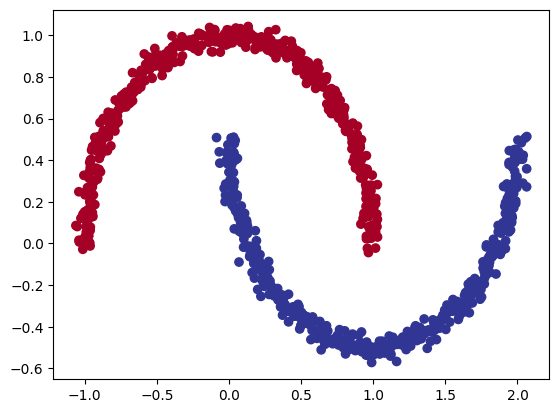

In [148]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [149]:
X_sample = X[0]
y_sample = y[0]
X_sample.shape, y_sample.shape

((2,), ())

In [150]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

In [152]:
class ExcerciseModelv0(nn.Module):
  def __init__(self, in_features, out_features, hidden_units):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=in_features, out_features=hidden_units)
    self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
    self.layer_3 = nn.Linear(in_features=hidden_units, out_features=out_features)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_5 = ExcerciseModelv0(in_features=2, out_features=1, hidden_units=10).to(device)
model_5

ExcerciseModelv0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [153]:
model_5.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [154]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_5.parameters(), lr=0.1)

In [155]:
print("logits: ")
print(model_5(X_train.to(device)[:10]).squeeze())

print("Pred probs: ")
print(torch.sigmoid(model_5(X_train.to(device)[:10]).squeeze()))

print("Pred labels: ")
print(torch.round(torch.sigmoid(model_5(X_train.to(device)[:10]).squeeze())))

logits: 
tensor([0.0016, 0.0098, 0.0175, 0.0183, 0.0287, 0.0182, 0.0310, 0.0180, 0.0242,
        0.0082], device='cuda:0', grad_fn=<SqueezeBackward0>)
Pred probs: 
tensor([0.5004, 0.5025, 0.5044, 0.5046, 0.5072, 0.5046, 0.5077, 0.5045, 0.5060,
        0.5020], device='cuda:0', grad_fn=<SigmoidBackward0>)
Pred labels: 
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
       grad_fn=<RoundBackward0>)


In [156]:
torch.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_5.train()
  y_logit = model_5(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logit))
  loss = loss_fn(y_logit, y_train)
  acc = accuracy_score(y_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_5.eval()

  with torch.inference_mode():
    test_logit = model_5(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logit))
    test_loss = loss_fn(test_logit, y_test)
    test_acc = accuracy_score(y_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69537 | Accuracy: 0.38% | test Loss: 0.69457 | Test Accuracy: 0.49%
Epoch: 100 | Loss: 0.38636 | Accuracy: 0.82% | test Loss: 0.40196 | Test Accuracy: 0.77%
Epoch: 200 | Loss: 0.23664 | Accuracy: 0.89% | test Loss: 0.23758 | Test Accuracy: 0.90%
Epoch: 300 | Loss: 0.19082 | Accuracy: 0.91% | test Loss: 0.18528 | Test Accuracy: 0.93%
Epoch: 400 | Loss: 0.15147 | Accuracy: 0.94% | test Loss: 0.14452 | Test Accuracy: 0.94%
Epoch: 500 | Loss: 0.10692 | Accuracy: 0.96% | test Loss: 0.09974 | Test Accuracy: 0.97%
Epoch: 600 | Loss: 0.06902 | Accuracy: 0.98% | test Loss: 0.06298 | Test Accuracy: 0.99%
Epoch: 700 | Loss: 0.04417 | Accuracy: 1.00% | test Loss: 0.03936 | Test Accuracy: 0.99%
Epoch: 800 | Loss: 0.03007 | Accuracy: 1.00% | test Loss: 0.02625 | Test Accuracy: 1.00%
Epoch: 900 | Loss: 0.02188 | Accuracy: 1.00% | test Loss: 0.01887 | Test Accuracy: 1.00%


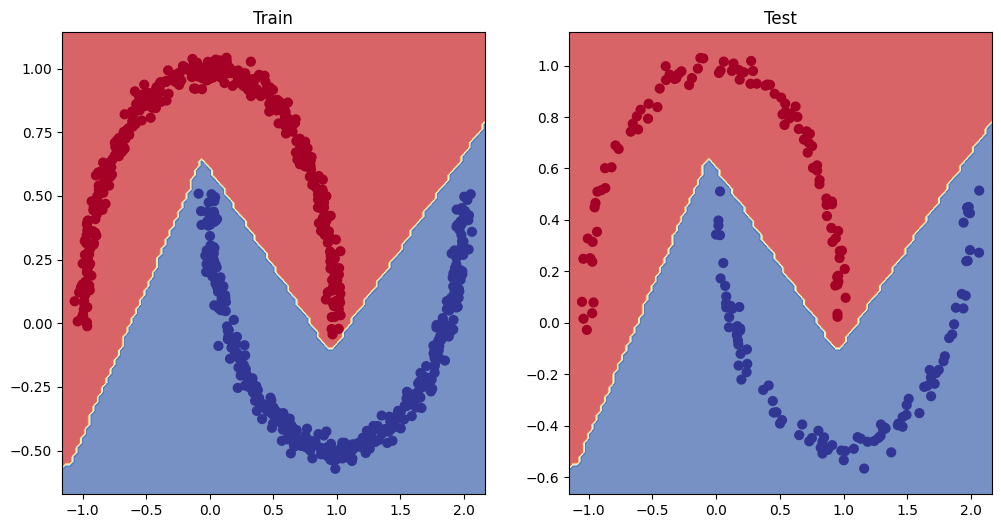

In [157]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_5, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_5, X_test, y_test)

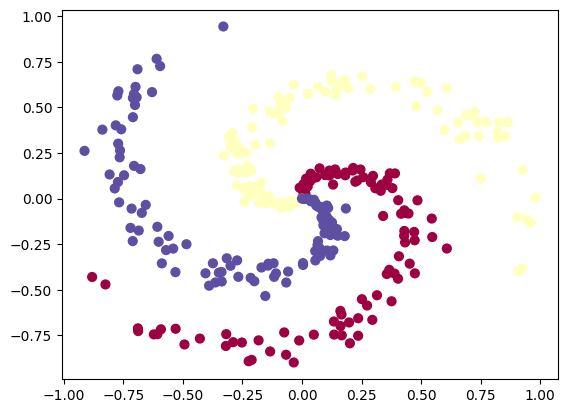

In [158]:
torch.manual_seed(42)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [159]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(240, 240, 60, 60)

In [160]:
class spiralModelv0(nn.Module):
  def __init__(self, in_features, out_features, hidden_units):
    super().__init__()
    self.layer1 = nn.Linear(in_features=in_features, out_features=hidden_units)
    self.layer2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
    self.layer3 = nn.Linear(in_features=hidden_units, out_features=out_features)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_6 = spiralModelv0(in_features=2, out_features=3, hidden_units=10).to(device)
model_6

spiralModelv0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [161]:
model_6.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, 

In [162]:
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print("Logit")
print(model_6(X_train)[:10])

print("Predicated Probability: ")
print(torch.softmax(model_6(X_train)[:10], dim=1))

print("Predicated Labels: ")
print(torch.softmax(model_6(X_train)[:10], dim=1).argmax(dim=1))

Logit
tensor([[-0.2154, -0.0594,  0.2265],
        [-0.2035, -0.0523,  0.2290],
        [-0.2231, -0.0611,  0.2380],
        [-0.2183, -0.0484,  0.2928],
        [-0.2218, -0.0563,  0.2770],
        [-0.2183, -0.0561,  0.2443],
        [-0.2209, -0.0580,  0.2438],
        [-0.2194, -0.0620,  0.2264],
        [-0.2054, -0.0530,  0.2294],
        [-0.2175, -0.0514,  0.2935]], device='cuda:0',
       grad_fn=<SliceBackward0>)
Predicated Probability: 
tensor([[0.2685, 0.3138, 0.4177],
        [0.2700, 0.3140, 0.4160],
        [0.2658, 0.3126, 0.4216],
        [0.2596, 0.3077, 0.4328],
        [0.2613, 0.3084, 0.4303],
        [0.2656, 0.3124, 0.4219],
        [0.2654, 0.3123, 0.4223],
        [0.2679, 0.3136, 0.4185],
        [0.2696, 0.3140, 0.4164],
        [0.2599, 0.3069, 0.4333]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Predicated Labels: 
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [163]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_6.parameters(), lr=0.02)

In [164]:
epochs = 1000

for epoch in range(epochs):
  model_6.train()
  y_logits = model_6(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_score(y_train.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_6.eval()

  with torch.inference_mode():
    test_logits = model_6(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_score(y_test.detach().cpu().numpy(), test_pred.detach().cpu().numpy())

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.11734 | Accuracy: 0.33% | test Loss: 1.10424 | Test Accuracy: 0.37%
Epoch: 100 | Loss: 0.49308 | Accuracy: 0.73% | test Loss: 0.60707 | Test Accuracy: 0.65%
Epoch: 200 | Loss: 0.23522 | Accuracy: 0.92% | test Loss: 0.31978 | Test Accuracy: 0.88%
Epoch: 300 | Loss: 0.07840 | Accuracy: 0.98% | test Loss: 0.07263 | Test Accuracy: 0.98%
Epoch: 400 | Loss: 0.03776 | Accuracy: 0.99% | test Loss: 0.02600 | Test Accuracy: 1.00%
Epoch: 500 | Loss: 0.02728 | Accuracy: 0.99% | test Loss: 0.01409 | Test Accuracy: 1.00%
Epoch: 600 | Loss: 0.02168 | Accuracy: 0.99% | test Loss: 0.00342 | Test Accuracy: 1.00%
Epoch: 700 | Loss: 0.01866 | Accuracy: 0.99% | test Loss: 0.00123 | Test Accuracy: 1.00%
Epoch: 800 | Loss: 0.01705 | Accuracy: 0.99% | test Loss: 0.00072 | Test Accuracy: 1.00%
Epoch: 900 | Loss: 0.01626 | Accuracy: 0.99% | test Loss: 0.00053 | Test Accuracy: 1.00%


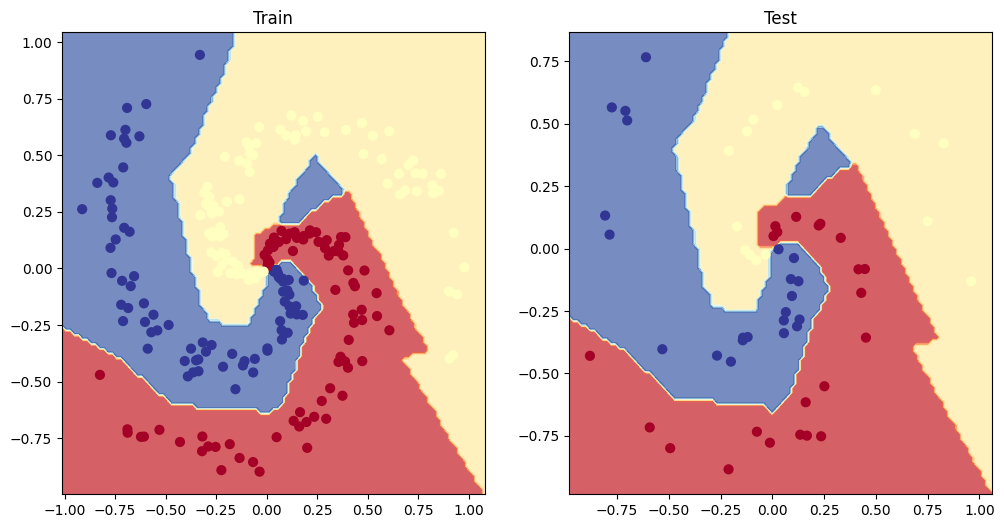

In [165]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_6, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_6, X_test, y_test)